In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii


plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

Mpc_cm = 3.086*10**24 #Mpc converted to cm
Jansky = 1e-23 #erg/s/cm^2/Hz

In [3]:
cendes_event_distances = ascii.read("cendes_distances.txt",delimiter='\t')

In [4]:
cendes2024=ascii.read("cendes_mrt.txt")
sfaradi_at2019azh = ascii.read("sfaradi_at2019azh.txt")
dist_at2019azh = 96*Mpc_cm #Mpc

In [5]:
cendes2024.add_column(col=-1,name='Distance (Mpc)')
for i,object_name in enumerate(cendes_event_distances['Object']):
    if object_name in np.unique(cendes2024['Object']):
        print(object_name)
        index = np.where(cendes2024['Object'] == object_name)[0][0]
        # print(cendes2024['Object'][index])
        # print(index)
        cendes2024['Distance (Mpc)'][index] = cendes_event_distances['Distance (Mpc)'][i]

iPTF16fnl
AT2019dsg
ASASSN-14ae
PS16dtm
AT2018zr
AT2018dyb
AT2018hco
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
iPTF15af
iPTF16axa
AT2017eqx
AT2018fyk
AT2018lna


In [6]:
cendes2024

Object,Tel,Code,Date,dt,Freq,l_S,S,e_S,Distance (Mpc)
,,,,d,GHz,,mJy,mJy,
str11,str7,str18,str12,int64,str5,str1,float64,float64,int64
iPTF16fnl,VLA,20A-492,2020 May 24,1365,6,--,0.045,0.001,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,3,<,0.514,--,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,5,--,0.028,0.008,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,7,--,0.031,0.007,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,9,--,0.024,0.006,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,11,--,0.023,0.008,-1
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.25,<,0.514,--,230
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.75,--,0.114,0.033,-1


In [7]:
dict_events = {}

for name in np.unique(np.array(cendes2024['Object'])):
    print(name)
    dt_array_temp = np.array([])
    freq_array_temp = np.array([])
    fluxdensity_array_temp = np.array([])
    err_fluxdensity_array_temp = np.array([])
    luminosity_array_temp = np.array([])
    err_luminosity_array_temp = np.array([])
    for i in range(len(cendes2024['Object'])):
        if cendes2024['Object'][i] == name:
            try:
                float(cendes2024['Freq'][i])
            except:
                continue
            # for i,object_name in enumerate(cendes_event_distances['Object']):
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            # print(cendes_event_distances['Object'][index])
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes2024['Object'][i], cendes2024['dt'][i],cendes2024['Freq'][i],cendes2024['S'][i],cendes2024['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes2024['dt'][i])
            freq_array_temp = np.append(freq_array_temp, float(cendes2024['Freq'][i]))
            fluxdensity_array_temp = np.append(fluxdensity_array_temp, cendes2024['S'][i])
            err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, cendes2024['e_S'][i])
            luminosity_array_temp = np.append(luminosity_array_temp, cendes2024['S'][i]*lum_fac)
            err_luminosity_array_temp = np.append(err_luminosity_array_temp, cendes2024['e_S'][i]*lum_fac)
    dict_events[name] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                         'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

ASASSN-14ae
AT2017eqx
AT2018dyb
AT2018fyk
AT2018hco
AT2018lna
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
PS16dtm
iPTF15af
iPTF16axa
iPTF16fnl


In [8]:
#use sfaradi_at2019azh for AT2019azh
dt_array_temp = np.array([])
freq_array_temp = np.array([])
fluxdensity_array_temp = np.array([])
err_fluxdensity_array_temp = np.array([])
luminosity_array_temp = np.array([])
err_luminosity_array_temp = np.array([])
lum_fac = 4*np.pi*(dist_at2019azh)**2 * Jansky * 1e-3

dt_array_temp = np.append(dt_array_temp, sfaradi_at2019azh['Days'])
freq_array_temp = np.append(freq_array_temp, np.full(len(sfaradi_at2019azh['Days']),15.5)) # GHZ
fluxdensity_array_temp = np.append(fluxdensity_array_temp, sfaradi_at2019azh['Flux'])
err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, sfaradi_at2019azh['e_Flux'])
luminosity_array_temp = np.append(luminosity_array_temp, sfaradi_at2019azh['Flux']*lum_fac)
err_luminosity_array_temp = np.append(err_luminosity_array_temp, sfaradi_at2019azh['e_Flux']*lum_fac)
dict_events['AT2019azh'] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                        'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

Note: Cendes paper talks about how AT2019dsg had extrapolation to 6 GHz to get luminosity from the plot. the others match ok with nuLnu

# loading TDE Flare Models

In [9]:
datadir_2flares_list = ['vmin_0p05c_vmax_0p4c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr/',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr']
names_2flares_list = [r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.05c$, $v_{\rm max} = 0.4c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=1$yr']

In [10]:
datadir_constism_list = ['constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs', 
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10000e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs']

names_constism_list = [r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$']

In [11]:
datadir_powerlawism_list = ['powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10000e-24_cgs', 
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100000e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1e+06e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_5e+06e-24_cgs',]

names_powerlawism_list = [r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 10000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 100000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 1e6 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 5e6 \times 10^{-24} \mathrm{g/cm^3}$']

# Peak data comparions

In [12]:
cendes_SED = ascii.read('cendes_SED.txt',delimiter='\t')

In [13]:
dict_SED_events = {}
for name in np.unique(cendes_SED['TDE']):
    dict_SED_events[name] = {}

    print(name)
    dt_array_temp = np.array([])

    peakfreq_array_temp = np.array([])
    uperr_peakfreq_array_temp = np.array([])
    loerr_peakfreq_array_temp = np.array([])

    peakfluxdensity_array_temp = np.array([])
    uperr_peakfluxdensity_array_temp = np.array([])
    loerr_peakfluxdensity_array_temp = np.array([])

    luminosity_array_temp = np.array([])
    uperr_luminosity_array_temp = np.array([])
    loerr_luminosity_array_temp = np.array([])

    powerlaw_p_temp = np.array([])
    uperr_powerlaw_p_temp = np.array([])
    loerr_powerlaw_p_temp = np.array([])

    for i in range(len(cendes_SED['TDE'])):
        if cendes_SED['TDE'][i] == name:
            try:
                median_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('_')[0].split('{')[1].split('}')[0])
                lolim_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('_')[1].split('{')[1].split('}')[0])
                uplim_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('^')[1].split('{')[1].split('}')[0])

                median_nu=float(cendes_SED['nu _p (GHz)'][i].split('_')[0].split('{')[1].split('}')[0])
                lolim_nu=float(cendes_SED['nu _p (GHz)'][i].split('_')[1].split('{')[1].split('}')[0])
                uplim_nu=float(cendes_SED['nu _p (GHz)'][i].split('^')[1].split('{')[1].split('}')[0])
            except:
                try:
                    median_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('>')[1])
                    uplim_Fnu=0
                    lolim_Fnu=0

                    median_nu=float(cendes_SED['nu _p (GHz)'][i].split('<')[1])
                    uplim_nu=0
                    lolim_nu=0
                except:
                    print(f'Error in {name} SED data')
                    continue
            median_pindex=float(cendes_SED['p'][i].split('_')[0].split('{')[1].split('}')[0])
            lolim_pindex=float(cendes_SED['p'][i].split('_')[1].split('{')[1].split('}')[0])
            uplim_pindex=float(cendes_SED['p'][i].split('^')[1].split('{')[1].split('}')[0])
            powerlaw_p_temp = np.append(powerlaw_p_temp, median_pindex)
            uperr_powerlaw_p_temp = np.append(uperr_powerlaw_p_temp, uplim_pindex)
            loerr_powerlaw_p_temp = np.append(loerr_powerlaw_p_temp, lolim_pindex)
            
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes_SED['Object'][i], cendes_SED['dt'][i],cendes_SED['Freq'][i],cendes_SED['S'][i],cendes_SED['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes_SED['delta t (days)'][i])
            peakfreq_array_temp = np.append(peakfreq_array_temp, median_nu)
            uperr_peakfreq_array_temp = np.append(uperr_peakfreq_array_temp, uplim_nu)
            loerr_peakfreq_array_temp = np.append(loerr_peakfreq_array_temp, lolim_nu)


            peakfluxdensity_array_temp = np.append(peakfluxdensity_array_temp, median_Fnu)
            uperr_peakfluxdensity_array_temp = np.append(uperr_peakfluxdensity_array_temp, uplim_Fnu)
            loerr_peakfluxdensity_array_temp = np.append(loerr_peakfluxdensity_array_temp, lolim_Fnu)

            luminosity_array_temp = np.append(luminosity_array_temp, median_Fnu*lum_fac)
            uperr_luminosity_array_temp = np.append(uperr_luminosity_array_temp, uplim_Fnu*lum_fac)
            loerr_luminosity_array_temp = np.append(loerr_luminosity_array_temp, lolim_Fnu*lum_fac)

    dict_SED_events[name] = {'epoch (d)': dt_array_temp, 'peak freq (GHz)': peakfreq_array_temp, 'peak freq uperr (GHz)':uperr_peakfreq_array_temp,'peak freq loerr (GHz)':loerr_peakfreq_array_temp, 
                         'peak flux density (mJy)': peakfluxdensity_array_temp, 'peak flux uperr (mJy)': uperr_peakfreq_array_temp, 'peak flux loerr (mJy)': loerr_peakfluxdensity_array_temp,
                         'peak Lnu (erg/s/Hz)': luminosity_array_temp, 'peak Lnu uperr (erg/s/Hz)': uperr_luminosity_array_temp, 'peak Lnu loerr (erg/s/Hz)': loerr_luminosity_array_temp,
                         'power law index p': powerlaw_p_temp, 'power law uperr (p)': uperr_powerlaw_p_temp, 'power law loerr (p)': loerr_powerlaw_p_temp}

ASASSN-14ae
AT2018dyb
AT2018hco
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
PS16dtm
iPTF16fnl


ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0, 0.5, 'Peak $L_{\\nu}$ (erg/s/Hz)')

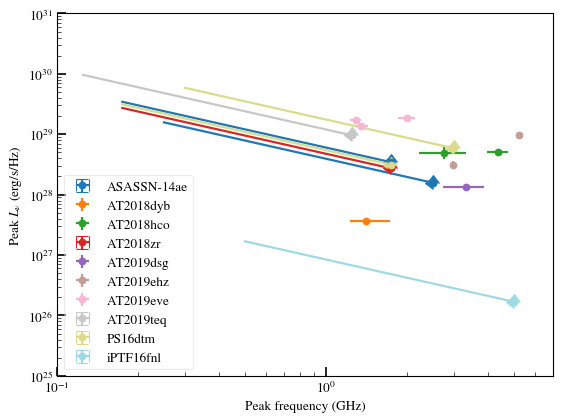

In [14]:
handles_list = []
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(0.1,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i])
plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(0.1,7)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')

ASASSN-14ae lower limit on Lnu,p only
AT2018zr lower limit on Lnu,p only
AT2019teq lower limit on Lnu,p only
PS16dtm lower limit on Lnu,p only
iPTF16fnl lower limit on Lnu,p only


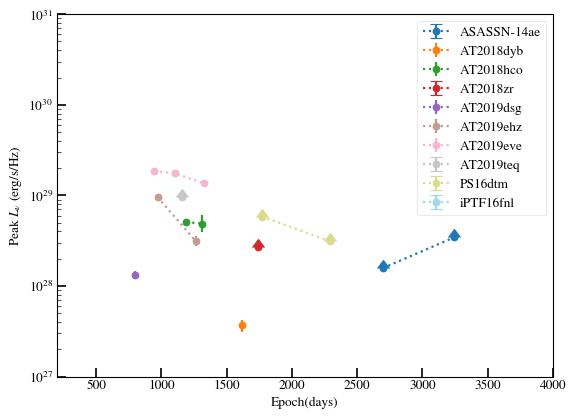

In [15]:
handles_list = []
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])
    ax.errorbar(dict_SED_events[event_name]['epoch (d)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,fmt='o',lolims=lolims,ms=6,
                label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
ax.set_xlim(200,4000)
ax.set_ylim(1e27,1e31)
ax.set_xlabel('Epoch(days)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
# ax.set_xscale('log')
ax.set_yscale('log')  

## Power law circumnuclear density

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, 'Power-law density ISM models')

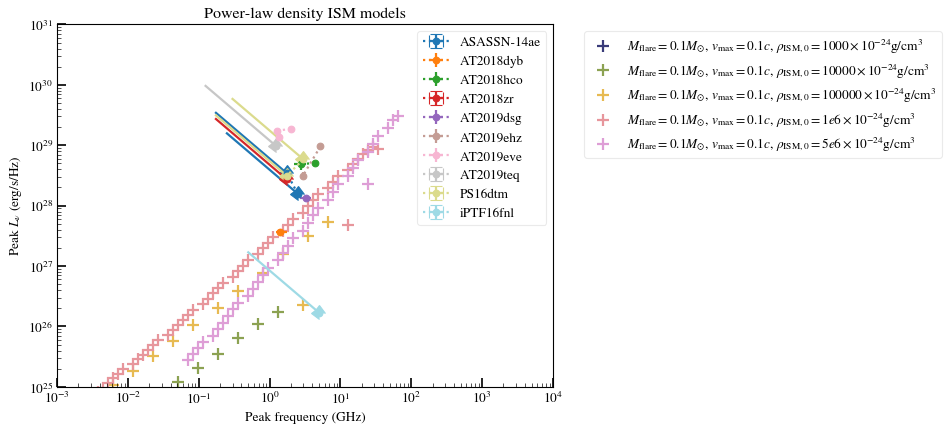

In [16]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(0.1,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_powerlawism_list)))
for i,datadir in enumerate(datadir_powerlawism_list):

    flare2_dict = {}


    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_powerlawism_list[i],marker='+')
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('Power-law density ISM models')

Conclusion: except for iPTF16fnl and AT2018dyb, the power law density ISM models cannot explain the peak Lnu and peak frequency of these events.

## Constant density ISM

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, 'Constant density ISM models')

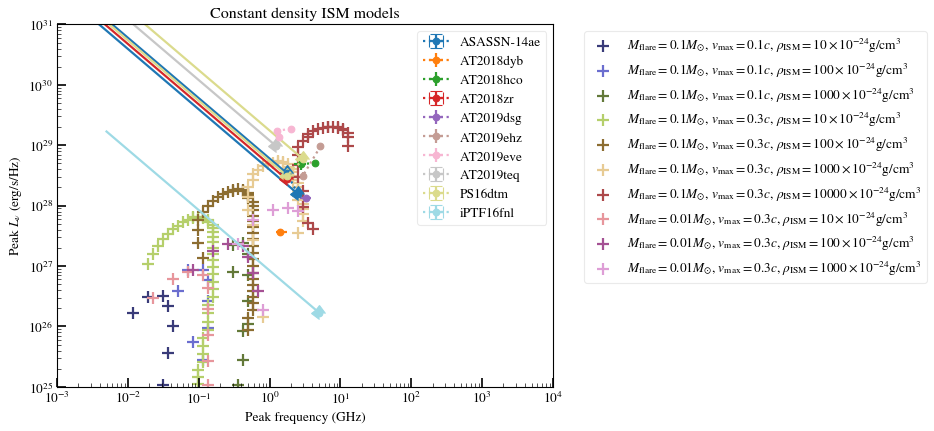

In [18]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    # print(dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'])
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(1e-3,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))
for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}


    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_constism_list[i],marker='+')
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('Constant density ISM models')

For iPTF16fnl: Mflare=0.1Msun/vmax=0.3c/rhoISM=10-100 and Mflare=0.01Msun/vmax=0.3c/rhoISM=100-1000 and Mflare=0.1Msun/vmax=0.1c/rhoISM=1000 all fit

for others: keep Mflare=0.1Msun/vmax=0.3c/rhoISM=100,1000,1e4 only. Maybe Mflare=0.01Msun/vmax=0.3c/rhoISM=1000 is ok for AT2018dyb.

## Two flares colliding

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, '2-flare models')

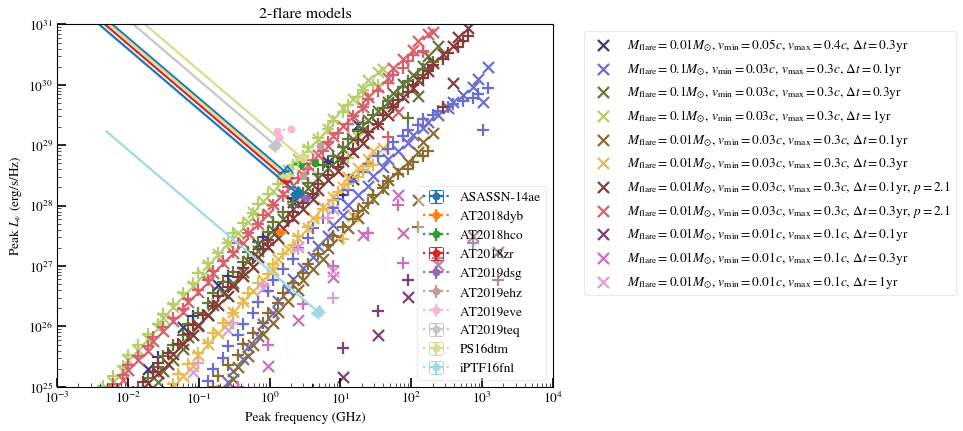

In [20]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(1e-3,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':',zorder=10)
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))
for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['peak_data'] = np.load(datadir+'/flare1/'+'peak_data.npz')
    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    ax.scatter(flare1_dict['peak_data']['nu_pk']/1e9, flare1_dict['peak_data']['Lnu_pk'],color=colors_array[i],marker='+')
    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_2flares_list[i],marker='x',zorder=0)
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('2-flare models')